# Case4 extreme anisotropy with partial observation

## Pacakages and Functions

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # the git/ folder, where utility.py lives
from utility import *  
import torch
import numpy as np
from inc_ensf import EnSF
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import math
from scipy.linalg import qr
from matplotlib.collections import LineCollection
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator

use_this = 'cuda:7'

In [2]:
def cov_generate(n,lambda_1):
    # n: dimension
    # 1. Direction of the line (e.g., all ones)
    v = np.ones(n)
    v /= np.linalg.norm(v)  # Normalize

    # 2. Create an orthonormal basis using QR decomposition
    # Stack v with random orthogonal vectors
    random_matrix = np.random.randn(n, n)
    random_matrix[:, 0] = v  # Set first column as v

    # QR gives orthonormal basis
    Q, _ = qr(random_matrix)  # Q is orthonormal, v is Q[:, 0]
    Lambda = np.diag([lambda_1 * 10**(-i) for i in range(n)]) 

    # 4. Build covariance matrix
    Sigma = Q @ Lambda @ Q.T  # Q * diag * Q^T
    Sigma += 1e-3 * np.eye(Sigma.shape[0])  # add jitter
    return Sigma


## generate sample

In [3]:
#test question
N_dim=10
ensemble_size = 10000
main_var = 1000000
# generate samples
torch.manual_seed(100)
np.random.seed(8)
mean = torch.zeros(N_dim, device= use_this, dtype=torch.float32)
covariance_matrix = torch.tensor(cov_generate(N_dim,main_var), device= use_this, dtype=torch.float32)
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix)
test_sample = mvn.sample(sample_shape=(ensemble_size,))
test_sample[0] = 0
# print(test_sample.mean(dim=0),"\n",test_sample.T.cov(), "\n",torch.linalg.cond(covariance_matrix))


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


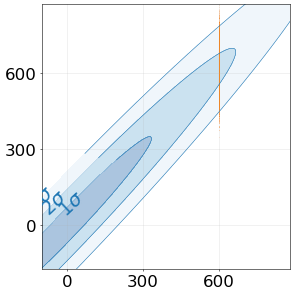

In [4]:
def to_numpy(a):
    return a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)

test_all = to_numpy(test_sample)
# # =========================
# # 1) Build "result" samples by conditioning on x[d0] = x0_obs
# # =========================


Sigma = covariance_matrix.detach().cpu().numpy() if hasattr(covariance_matrix, "detach") else np.asarray(covariance_matrix)
n = Sigma.shape[0]

d0 = 0          # observed dimension
y  = 600     
sigma_obs = 0.1  


R = sigma_obs**2  # scalar

# Kalman gain (n,)
K = Sigma[:, d0] / (Sigma[d0, d0] + R)

# Posterior mean (n,)
mu_a = K * y

# Posterior covariance (n,n)
Sigma_a = Sigma - np.outer(Sigma[:, d0], Sigma[d0, :]) / (Sigma[d0, d0] + R)

# Sample posterior
rng = np.random.default_rng(123)
result_all = rng.multivariate_normal(mu_a, Sigma_a, size=ensemble_size)

for i in range(1):
    for j in range(i+1,2):
        dim_plot = [i,j]
        # choose 2D projection dims
        d0, d1 = dim_plot[0], dim_plot[1]
        # 2D arrays for plotting
        test   = test_all[:, [d0, d1]]
        result = result_all[:, [d0, d1]]

        # means/covs in 2D
        mean_test   = test.mean(axis=0)
        cov_test    = np.cov(test.T)

        mean_result = result.mean(axis=0)
        cov_result  = np.cov(result.T)
        ref_loc = mean_result.copy()
        # =========================
        # 2) Ellipse helper (yours)
        # =========================
        def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 0))
            ellipse = Ellipse(xy=pos, width=width, height=height, angle=angle, **kwargs)
            ax.add_patch(ellipse)
            return ellipse

        # =========================
        # 3) Plot: prior vs post + path + ellipses
        # =========================
        fig, ax = plt.subplots(figsize=(6, 6),dpi=50)

        # scatter (keep s tiny; enlarge legend markers separately)
        # --- prior as Gaussian contour (replaces the prior scatter) ---
        pad = 0.1
        gx = np.linspace(test[:, 0].min() - pad * np.ptp(test[:, 0]),
                        test[:, 0].max() + pad * np.ptp(test[:, 0]), 400)
        gy = np.linspace(test[:, 1].min() - pad * np.ptp(test[:, 1]),
                        test[:, 1].max() + pad * np.ptp(test[:, 1]), 400)
        xx, yy = np.meshgrid(gx, gy)
        grid = np.stack([xx.ravel(), yy.ravel()], axis=1) - mean_test
        cov_inv = np.linalg.inv(cov_test)
        maha = np.sqrt(np.einsum('ij,jk,ik->i', grid, cov_inv, grid)).reshape(xx.shape)
        def on_contour(k, theta_deg):
            """Point on the k-sigma contour along direction theta (degrees in the data plane:
            0 = right, 90 = up, 45 = up the long axis, 135 = across the short axis)."""
            u = np.array([np.cos(np.radians(theta_deg)), np.sin(np.radians(theta_deg))])
            r = k / np.sqrt(u @ cov_inv @ u)
            return mean_test + r * u
        # filled shading (drop this line if you only want lines)
        ax.contourf(xx, yy, maha, levels=[0, 1, 2, 3], cmap='Blues_r', alpha=0.35)
        # contour lines at 1σ, 2σ, 3σ (Mahalanobis distance)
        cs = ax.contour(xx, yy, maha, levels=[1, 2, 3], colors='tab:blue', linewidths=0.8)
        # ax.clabel(cs, fmt={1: r'1$\sigma$', 2: r'2$\sigma$', 3: r'3$\sigma$'}, fontsize=28,
        #     manual=[on_contour(1, 80), on_contour(2, 60), on_contour(3, 55)])
        ax.clabel(cs, fmt={1: r'1$\sigma$', 2: r'2$\sigma$', 3: r'3$\sigma$'}, fontsize=28,
            manual=[on_contour(1, 80), on_contour(2, 120), on_contour(3, 135)])
        ax.scatter(result[:, 0], result[:, 1], alpha=0.5, label="post (cond)", s=0.04, color="tab:orange")
        
        # covariance ellipses
        plot_cov_ellipse(cov_test,   mean_test,   ax, edgecolor="tab:blue", facecolor="none", linewidth=0.1,
                        label="Cov ellipse prior")
        plot_cov_ellipse(cov_result, mean_result, ax, edgecolor="tab:orange",  facecolor="none", linewidth=0.1,
                        label="Cov ellipse post")
        
        ax.axis("equal")

        ax.set_xlim(-100, 880)
        ax.set_ylim(-100, 800)
        ax.xaxis.set_major_locator(MultipleLocator(300))   # x-axis tick every 5
        ax.yaxis.set_major_locator(MultipleLocator(300))   # y-axis tick every 5

        ax.tick_params(axis='both', which='major', labelsize=24)
        ax.grid(alpha = 0.3)
        #ax.legend(markerscale=25)  # enlarge legend markers only
        plt.tight_layout()
        sigma_str = "mix"#f"{sigma_obs:g}".replace(".", "p")
        plt.show()
        plt.close()

## EnSF

### ensemble-mean paths 100 iterations

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


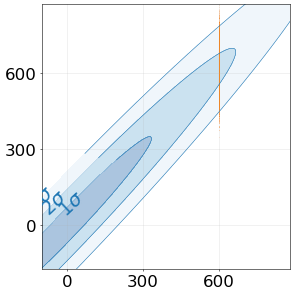

In [5]:
testensf = EnSF(n_dim = N_dim, ensemble_size = ensemble_size ,eps_alpha=0.01, eps_beta= 0.00, device= use_this ,obs_sigma = 5, euler_steps = 1)
result1 = testensf.RSDE_inc(obs=600, x0=0, x_prior=test_sample.clone(), time_steps=100, ens_cov=covariance_matrix/25000, sparse_idx=[0],cov_scale = 25000, tau_scale = 1) 

#path mean
for i in range(1):
    for j in range(i+1,2):
        dim_plot = [i,j]
        # choose 2D projection dims
        d0, d1 = dim_plot[0], dim_plot[1]
        # 2D arrays for plotting
        test   = test_all[:, [d0, d1]]
        result = result_all[:, [d0, d1]]

        # means/covs in 2D
        mean_test   = test.mean(axis=0)
        cov_test    = np.cov(test.T)

        mean_result = result.mean(axis=0)
        cov_result  = np.cov(result.T)
        ref_loc = mean_result.copy()
        # =========================
        # 2) Ellipse helper (yours)
        # =========================
        def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * n_std * np.sqrt(np.maximum(eigvals, 0))
            ellipse = Ellipse(xy=pos, width=width, height=height, angle=angle, **kwargs)
            ax.add_patch(ellipse)
            return ellipse

        # =========================
        # 3) Plot: prior vs post + path + ellipses
        # =========================
        fig, ax = plt.subplots(figsize=(6, 6),dpi=50)

        # scatter (keep s tiny; enlarge legend markers separately)
        # --- prior as Gaussian contour (replaces the prior scatter) ---
        pad = 0.1
        gx = np.linspace(test[:, 0].min() - pad * np.ptp(test[:, 0]),
                        test[:, 0].max() + pad * np.ptp(test[:, 0]), 400)
        gy = np.linspace(test[:, 1].min() - pad * np.ptp(test[:, 1]),
                        test[:, 1].max() + pad * np.ptp(test[:, 1]), 400)
        xx, yy = np.meshgrid(gx, gy)
        grid = np.stack([xx.ravel(), yy.ravel()], axis=1) - mean_test
        cov_inv = np.linalg.inv(cov_test)
        maha = np.sqrt(np.einsum('ij,jk,ik->i', grid, cov_inv, grid)).reshape(xx.shape)
        def on_contour(k, theta_deg):
            """Point on the k-sigma contour along direction theta (degrees in the data plane:
            0 = right, 90 = up, 45 = up the long axis, 135 = across the short axis)."""
            u = np.array([np.cos(np.radians(theta_deg)), np.sin(np.radians(theta_deg))])
            r = k / np.sqrt(u @ cov_inv @ u)
            return mean_test + r * u
        # filled shading (drop this line if you only want lines)
        ax.contourf(xx, yy, maha, levels=[0, 1, 2, 3], cmap='Blues_r', alpha=0.35)
        # contour lines at 1σ, 2σ, 3σ (Mahalanobis distance)
        cs = ax.contour(xx, yy, maha, levels=[1, 2, 3], colors='tab:blue', linewidths=0.8)
        # ax.clabel(cs, fmt={1: r'1$\sigma$', 2: r'2$\sigma$', 3: r'3$\sigma$'}, fontsize=28,
        #     manual=[on_contour(1, 80), on_contour(2, 60), on_contour(3, 55)])
        ax.clabel(cs, fmt={1: r'1$\sigma$', 2: r'2$\sigma$', 3: r'3$\sigma$'}, fontsize=28,
            manual=[on_contour(1, 80), on_contour(2, 120), on_contour(3, 135)])
        ax.scatter(result[:, 0], result[:, 1], alpha=0.5, label="post (cond)", s=0.04, color="tab:orange")
        
        # covariance ellipses
        plot_cov_ellipse(cov_test,   mean_test,   ax, edgecolor="tab:blue", facecolor="none", linewidth=0.1,
                        label="Cov ellipse prior")
        plot_cov_ellipse(cov_result, mean_result, ax, edgecolor="tab:orange",  facecolor="none", linewidth=0.1,
                        label="Cov ellipse post")
        
        ax.axis("equal")

        ax.set_xlim(-100, 880)
        ax.set_ylim(-100, 800)
        ax.xaxis.set_major_locator(MultipleLocator(300))   # x-axis tick every 5
        ax.yaxis.set_major_locator(MultipleLocator(300))   # y-axis tick every 5

        ax.tick_params(axis='both', which='major', labelsize=24)
        ax.grid(alpha = 0.3)
        #ax.legend(markerscale=25)  # enlarge legend markers only
        plt.tight_layout()
        sigma_str = "mix"#f"{sigma_obs:g}".replace(".", "p")
        plt.show()
        plt.close()

## 3DEnVar

### ensemble-mean paths

Iteration 1: Cost = 23409334.000000
Iteration 2: Cost = 6548163.000000
Iteration 3: Cost = 2185846.000000
Iteration 4: Cost = 743088.625000
Iteration 5: Cost = 256762.562500
Iteration 6: Cost = 92506.125000
Iteration 7: Cost = 36922.417969
Iteration 8: Cost = 18022.531250
Iteration 9: Cost = 11513.767578
Iteration 10: Cost = 9197.243164
Iteration 11: Cost = 8305.063477
Iteration 12: Cost = 7902.242188
Iteration 13: Cost = 7672.441406
Iteration 14: Cost = 7508.187012
Iteration 15: Cost = 7372.563965
Iteration 16: Cost = 7252.524414
Iteration 17: Cost = 7143.135742
Iteration 18: Cost = 7042.249512
Iteration 19: Cost = 6948.701660
Iteration 20: Cost = 6861.700684
Iteration 21: Cost = 6780.617188
Iteration 22: Cost = 6704.911621
Iteration 23: Cost = 6634.102051
Iteration 24: Cost = 6567.754395
Iteration 25: Cost = 6505.476074
Iteration 26: Cost = 6446.909668
Iteration 27: Cost = 6391.732422
Iteration 28: Cost = 6339.650879
Iteration 29: Cost = 6290.396484
Iteration 30: Cost = 6243.726074
I

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


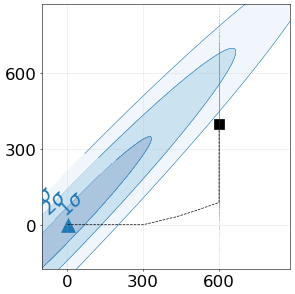

In [6]:
#sparse obs
H = lambda x: x
obs = torch.tensor((600))
# Create EnVar instance
# replace with __all__ = ['EnVar3D', 'CVT3dEnVar', 'CVT3dEnVarPerturbedObs', 'EnVar3DPerturbedObs']
envar = EnVar3D(H=H, y_obs=obs, B = covariance_matrix, R=torch.eye(N_dim)*0.01, Xb= test_sample.clone(),obs_idx=[0], learning_rate=0.005, max_iterations=50000, convergence_threshold=1e-6,device=use_this)
x_analysis,nan_idx, x_path = envar.run()

#path mean
plot_endpont = -1
x = (x_path).cpu().detach().numpy()
for i in range(1):
    for j in range(i+1,2):
        dim_plot = [i,j]
        rotated_test_sample = test_sample[:,dim_plot] 
        d0, d1 = dim_plot[0], dim_plot[1]
        ref_loc = result_all[:, [d0, d1]].mean(axis=0)
        test = rotated_test_sample.cpu().numpy()  #rotated_test_sample
        result = x[plot_endpont][:, dim_plot]
        # Define the 2D covariance matrix
        cov_test = np.cov(test.T)
        cov_result = np.cov(result.T)

        # Mean of the distribution (center of the ellipse)
        mean_test = test.mean(axis = 0)
        mean_result = result.mean(axis = 0)
        # Generate samples from the multivariate normal distribution

        # Plot the samples
        fig, ax = plt.subplots(figsize=(6, 6),dpi=50)
        # --- prior as Gaussian contour (replaces the prior scatter) ---
        pad = 0.1
        gx = np.linspace(test[:, 0].min() - pad * np.ptp(test[:, 0]),
                        test[:, 0].max() + pad * np.ptp(test[:, 0]), 400)
        gy = np.linspace(test[:, 1].min() - pad * np.ptp(test[:, 1]),
                        test[:, 1].max() + pad * np.ptp(test[:, 1]), 400)
        xx, yy = np.meshgrid(gx, gy)
        grid = np.stack([xx.ravel(), yy.ravel()], axis=1) - mean_test
        cov_inv = np.linalg.inv(cov_test)
        maha = np.sqrt(np.einsum('ij,jk,ik->i', grid, cov_inv, grid)).reshape(xx.shape)
        def on_contour(k, theta_deg):
            """Point on the k-sigma contour along direction theta (degrees in the data plane:
            0 = right, 90 = up, 45 = up the long axis, 135 = across the short axis)."""
            u = np.array([np.cos(np.radians(theta_deg)), np.sin(np.radians(theta_deg))])
            r = k / np.sqrt(u @ cov_inv @ u)
            return mean_test + r * u
        # filled shading (drop this line if you only want lines)
        ax.contourf(xx, yy, maha, levels=[0, 1, 2, 3], cmap='Blues_r', alpha=0.35)
        # contour lines at 1σ, 2σ, 3σ (Mahalanobis distance)
        cs = ax.contour(xx, yy, maha, levels=[1, 2, 3], colors='tab:blue', linewidths=0.8)
        # ax.clabel(cs, fmt={1: r'1$\sigma$', 2: r'2$\sigma$', 3: r'3$\sigma$'}, fontsize=28,
        #   manual=[on_contour(1, 80), on_contour(2, 60), on_contour(3, 55)])
        ax.clabel(cs, fmt={1: r'1$\sigma$', 2: r'2$\sigma$', 3: r'3$\sigma$'}, fontsize=28,
            manual=[on_contour(1, 80), on_contour(2, 120), on_contour(3, 135)])

        ax.scatter(result[:, 0], result[:, 1], alpha=0.5, label="post", s=0.04, color = "tab:orange")

        # Function to draw the covariance ellipse
        def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:, order]
            angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
            width, height = 2 * n_std * np.sqrt(eigvals)
            ellipse = Ellipse(xy=pos, width=width, height=height, angle=angle, **kwargs)
            ax.add_patch(ellipse)

        # Draw the ellipse
        plot_cov_ellipse(cov_test,mean_test, ax, edgecolor='tab:blue', facecolor='none', linewidth=0.1, label='Covariance Ellipse Prior')
        plot_cov_ellipse(cov_result,mean_result, ax, edgecolor='tab:orange', facecolor='none', linewidth=0.1, label='Covariance Ellipse post')
        #mark the reference point
        ensf_path = x[:plot_endpont,:,dim_plot].mean(axis=1)
        px, py = ensf_path[:, 0], ensf_path[:, 1]
        plt.plot(px, py,'--',linewidth=1,color = "black", label='EnSF')

        def arrow_at(ax, x, y, idx, color='black', size=58, lw=1, back=50, tail_pt=0.5):
            """Open '>' arrowhead at point idx, oriented along the local path direction."""
            j = max(idx - back, 0)
            d = np.array([x[idx] - x[j], y[idx] - y[j]])
            d /= np.linalg.norm(d) + 1e-12
            ax.annotate('', xy=(x[idx], y[idx]),
                        xytext=(-tail_pt * d[0], -tail_pt * d[1]), textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', color=color, mutation_scale=size,
                                        lw=lw, shrinkA=0, shrinkB=0), zorder=6)


        ax.scatter(mean_test[0], mean_test[1], marker='^', alpha=1, color ="tab:blue" ,label="reference", s=400)
        ax.scatter(mean_result[0], mean_result[1], marker='s',alpha=1, color ="black" ,label="reference", s=200)
        ax.axis('equal')

        ax.set_xlim(-100, 880)
        ax.set_ylim(-100, 800)
        ax.xaxis.set_major_locator(MultipleLocator(300))   # x-axis tick every 5
        ax.yaxis.set_major_locator(MultipleLocator(300))   # y-axis tick every 5
        ax.tick_params(axis='both', which='major', labelsize=24)

        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close()